# 06 — Choosing the embedder and the hybrid weight

Two retrieval choices: which embedding model (all-MiniLM-L6-v2, multi-qa-MiniLM or bge-small-en-v1.5) under each chunking strategy, and how much of the hybrid score comes from the embeddings rather than BM25 (`retriever.DENSE_WEIGHT`). The application uses bge-small, sentence chunking and a dense weight of 0.4.

**Running it.** Every section below is the evaluation's own code. With `RUN = False`
(the default) nothing is recomputed: the results saved in `data/eval/` are loaded
and shown. Set `RUN = True` in the first code cell to measure again, which
overwrites those files. Each part takes a few minutes.

In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath("") if os.path.basename(os.path.abspath("")) == "notebooks"
                else os.path.join(os.path.abspath(""), "notebooks"))
from eval_common import repo_root  # noqa: E402

REPO_ROOT = repo_root()
sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / "notebooks"))

# The application's settings (backend/service.py). They are read when the
# pipeline modules are imported, so they are set before anything else.
os.environ.setdefault("SA_EMBEDDER", "bge-small")

# False: show the results saved in data/eval. True: run the evaluation again
# and overwrite them (the run time is given at the top of the notebook).
RUN = False

In [2]:
import json

import pandas as pd

EVAL_DIR = REPO_ROOT / "data" / "eval"


def saved(name):
    """A results file from data/eval."""
    return json.loads((EVAL_DIR / name).read_text(encoding="utf-8"))

## Embedder by chunking strategy

Compares embedding models for retrieval on the 25-question ground truth.

Every earlier diagnostic points at the embedding model: the correct chunk
loses to other body text from the same paper (competitor_analysis.json), and
chunking changes move only one or two questions (retrieval_variants.json).
all-MiniLM-L6-v2 was never compared against alternatives, so this script
does that, holding everything else fixed:

```text
  all-MiniLM-L6-v2           the pipeline's model (22M parameters)
  multi-qa-MiniLM-L6-cos-v1  same architecture, trained for question answering
  bge-small-en-v1.5          a newer retrieval model of similar size (33M)
  all-mpnet-base-v2          a larger general-purpose model (110M)
```

Chunks come from preprocess() exactly as the pipeline makes them (chunk
boundaries are set with the MiniLM tokenizer, and semantic breaks with MiniLM
sentence vectors, so each model sees identical text), for all four chunking
modes: fixed windows, sentence-aware, heading-aware and semantic. bge expects
an instruction in front of queries; the other models take text as-is. Vectors are normalised
and searched exactly, so the ranking is by cosine similarity, which matches
IndexFlatL2 on unit vectors. Hit rule as in eval_recall.py: a retrieved
chunk from the expected file and page.

Each combination is scored twice: dense only, and hybrid (the same dense
scores mixed 40/60 with BM25 keyword scores, as retriever.py does). A
keyword-only row is scored once per chunking mode. Exact McNemar tests compare
each result with MiniLM dense retrieval on the same chunks.

In [3]:
# The script's command-line options, as it would have read them.
sys.argv = ['notebook']

In [4]:
import json
import os
import sys
import time
from math import comb
from pathlib import Path

ROOT = REPO_ROOT
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import numpy as np  # noqa: E402
from sentence_transformers import SentenceTransformer  # noqa: E402

from backend.pipeline.device import get_torch_device  # noqa: E402
from backend.pipeline.loader import load_file  # noqa: E402
from backend.pipeline.preprocessor import preprocess  # noqa: E402
from backend.pipeline import sparse  # noqa: E402
from backend.pipeline.retriever import DENSE_WEIGHT  # noqa: E402

RAW_DIR = ROOT / "data" / "raw"
EVAL_DIR = ROOT / "data" / "eval"
GROUND_TRUTH_PATH = EVAL_DIR / "retrieval_ground_truth.json"
OUT_PATH = EVAL_DIR / "embedder_comparison.json"

DOCUMENTS = [
    "embedding.pdf",
    "Whisper.pdf",
    "Flant5pdf.pdf",
    "Hallucinations_in_Large_Language_Models_LLMs.pdf",
]
MODELS = {
    "all-MiniLM-L6-v2": {"id": "sentence-transformers/all-MiniLM-L6-v2",
                         "query_prefix": ""},
    "multi-qa-MiniLM-L6-cos-v1": {"id": "sentence-transformers/multi-qa-MiniLM-L6-cos-v1",
                                  "query_prefix": ""},
    "bge-small-en-v1.5": {"id": "BAAI/bge-small-en-v1.5",
                          "query_prefix": "Represent this sentence for searching "
                                          "relevant passages: "},
    "all-mpnet-base-v2": {"id": "sentence-transformers/all-mpnet-base-v2",
                          "query_prefix": ""},
}
BASELINE = "all-MiniLM-L6-v2"
CHUNKINGS = ["window", "sentence", "heading", "semantic"]
K_VALUES = [1, 3, 5]

In [5]:
def mcnemar_p(gained: int, lost: int) -> float:
    n = gained + lost
    if n == 0:
        return 1.0
    tail = sum(comb(n, i) for i in range(min(gained, lost) + 1))
    return min(1.0, 2 * tail / 2 ** n)

In [6]:
def scaled(values):
    lo, hi = float(values.min()), float(values.max())
    return (values - lo) / ((hi - lo) or 1.0)

In [7]:
def evaluate(model, prefix, chunks, ground_truth, method="dense", bm25=None):
    t0 = time.time()
    doc_vecs = (model.encode([str(c) for c in chunks], normalize_embeddings=True,
                             convert_to_numpy=True, show_progress_bar=False,
                             batch_size=32) if model is not None else None)
    encode_sec = time.time() - t0
    q_vecs = (model.encode([prefix + e["question"] for e in ground_truth],
                           normalize_embeddings=True, convert_to_numpy=True,
                           show_progress_bar=False)
              if model is not None else [None] * len(ground_truth))

    ranks = []
    for q, entry in zip(q_vecs, ground_truth):
        expected = (entry["source_file"], entry["page"])
        if method == "dense":
            score = doc_vecs @ q
        else:
            keyword = np.asarray(bm25.scores(entry["question"]))
            score = (keyword if method == "keyword" else
                     DENSE_WEIGHT * scaled(doc_vecs @ q) + (1 - DENSE_WEIGHT) * scaled(keyword))
        top = np.argsort(-score, kind="stable")[:max(K_VALUES)]
        ranks.append(next((r for r, i in enumerate(top, 1)
                           if (chunks[i].source_file, chunks[i].page) == expected), None))

    total = len(ground_truth)
    return {
        "recall": {f"recall_at_{k}": round(sum(1 for r in ranks if r and r <= k) / total, 3)
                   for k in K_VALUES},
        "mrr_top5": round(float(np.mean([1 / r if r else 0 for r in ranks])), 4),
        "encode_sec_per_100_chunks": round(100 * encode_sec / len(chunks), 3),
        "ranks": ranks,
    }

In [8]:
def main():
    ground_truth = json.loads(GROUND_TRUTH_PATH.read_text(encoding="utf-8"))
    pages = [load_file(str(RAW_DIR / name)) for name in DOCUMENTS]
    chunk_sets = {mode: [c for p in pages for c in preprocess(p, chunking=mode)]
                  for mode in CHUNKINGS}
    device = get_torch_device()
    bm25_sets = {mode: sparse.build_index(c) for mode, c in chunk_sets.items()}

    results = {}
    for name, spec in MODELS.items():
        model = SentenceTransformer(spec["id"], device=device)
        info = {
            "hf_id": spec["id"],
            "parameters_millions": round(sum(p.numel() for p in model.parameters()) / 1e6, 1),
            "dimensions": model.get_sentence_embedding_dimension(),
            "max_seq_length": model.max_seq_length,
            "query_prefix": spec["query_prefix"],
        }
        results[name] = {**info, "by_chunking": {
            mode: evaluate(model, spec["query_prefix"], chunk_sets[mode], ground_truth)
            for mode in CHUNKINGS}}
        results[f"{name} + BM25"] = {**info, "by_chunking": {
            mode: evaluate(model, spec["query_prefix"], chunk_sets[mode], ground_truth,
                           method="hybrid", bm25=bm25_sets[mode])
            for mode in CHUNKINGS}}
        del model
    results["BM25 only"] = {"by_chunking": {
        mode: evaluate(None, "", chunk_sets[mode], ground_truth,
                       method="keyword", bm25=bm25_sets[mode])
        for mode in CHUNKINGS}}

    print(f"device: {device}\n")
    print(f"{'model':<34} {'params':>6} {'chunking':<9} {'R@1':>5} {'R@3':>5} "
          f"{'R@5':>5} {'MRR':>6} {'s/100':>6}  vs MiniLM at k=5 (gained/lost, p)")
    for name, r in results.items():
        for mode in CHUNKINGS:
            m = r["by_chunking"][mode]
            base = results[BASELINE]["by_chunking"][mode]["ranks"]
            for k in K_VALUES:
                hit = [x is not None and x <= k for x in m["ranks"]]
                base_hit = [x is not None and x <= k for x in base]
                gained = sum(a and not b for a, b in zip(hit, base_hit))
                lost = sum(b and not a for a, b in zip(hit, base_hit))
                m.setdefault("vs_baseline", {})[f"k={k}"] = {
                    "gained": gained, "lost": lost,
                    "mcnemar_p": round(mcnemar_p(gained, lost), 3)}
            v = m["vs_baseline"]["k=5"]
            rc = m["recall"]
            print(f"{name:<34} {r.get('parameters_millions', '-'):>6} {mode:<9} "
                  f"{rc['recall_at_1']:>5} {rc['recall_at_3']:>5} {rc['recall_at_5']:>5} "
                  f"{m['mrr_top5']:>6} {m['encode_sec_per_100_chunks']:>6}  "
                  f"{v['gained']}/{v['lost']}, p={v['mcnemar_p']}")

    OUT_PATH.write_text(json.dumps({
        "note": "Embedding-model comparison on the 25-question retrieval ground "
                "truth. ranks: first matching rank in the top 5, null if none.",
        "device": device,
        "chunks": {mode: len(c) for mode, c in chunk_sets.items()},
        "models": results,
    }, indent=2) + "\n", encoding="utf-8")
    print(f"\n  -> {OUT_PATH.relative_to(ROOT)}")

In [9]:
if RUN:
    main()
else:
    print('RUN is False: showing the saved results below.')

RUN is False: showing the saved results below.


### Results

In [10]:
ec = saved("embedder_comparison.json")
rows = []
for model, m in ec["models"].items():
    for chunking, r in m["by_chunking"].items():
        rows.append({"model": model, "chunking": chunking, "chunks": ec["chunks"][chunking],
                     **r["recall"], "MRR@5": r["mrr_top5"],
                     "encode s / 100 chunks": r["encode_sec_per_100_chunks"]})
pd.DataFrame(rows).set_index(["model", "chunking"]).round(3)

chunks  recall_at_1  recall_at_3  \
model                            chunking                                     
all-MiniLM-L6-v2                 window       581         0.44         0.56   
                                 sentence     635         0.52         0.60   
                                 heading      716         0.48         0.64   
                                 semantic     776         0.40         0.56   
all-MiniLM-L6-v2 + BM25          window       581         0.64         0.80   
                                 sentence     635         0.64         0.84   
                                 heading      716         0.72         0.80   
                                 semantic     776         0.68         0.88   
multi-qa-MiniLM-L6-cos-v1        window       581         0.40         0.60   
                                 sentence     635         0.44         0.60   
                                 heading      716         0.52         0.64   
                                 semantic     776         0.60         0.72   
multi-qa-MiniLM-L6-cos-v1 + BM25 window       581         0.72         0.80   
                                 sentence     635         0.76         0.84   
                                 heading      716         0.68         0.84   
                                 semantic     776         0.64         0.88   
bge-small-en-v1.5                window       581         0.56         0.72   
                                 sentence     635         0.60         0.72   
                                 heading      716         0.56         0.72   
                                 semantic     776         0.60         0.72   
bge-small-en-v1.5 + BM25         window       581         0.72         0.80   
                                 sentence     635         0.72         0.84   
                                 heading      716         0.72         0.76   
                                 semantic     776         0.72         0.88   
all-mpnet-base-v2                window       581         0.24         0.44   
                                 sentence     635         0.24         0.40   
                                 heading      716         0.36         0.52   
                                 semantic     776         0.40         0.48   
all-mpnet-base-v2 + BM25         window       581         0.64         0.84   
                                 sentence     635         0.64         0.84   
                                 heading      716         0.76         0.88   
                                 semantic     776         0.76         0.84   
BM25 only                        window       581         0.68         0.88   
                                 sentence     635         0.64         0.84   
                                 heading      716         0.76         0.88   
                                 semantic     776         0.80         0.84   

                                           recall_at_5  MRR@5  \
model                            chunking                       
all-MiniLM-L6-v2                 window           0.60  0.503   
                                 sentence         0.60  0.547   
                                 heading          0.64  0.553   
                                 semantic         0.60  0.481   
all-MiniLM-L6-v2 + BM25          window           0.88  0.731   
                                 sentence         0.92  0.740   
                                 heading          0.96  0.791   
                                 semantic         0.92  0.775   
multi-qa-MiniLM-L6-cos-v1        window           0.72  0.517   
                                 sentence         0.76  0.536   
                                 heading          0.72  0.598   
                                 semantic         0.84  0.681   
multi-qa-MiniLM-L6-cos-v1 + BM25 window           0.92  0.783   
                                 sentence         1.00  0.831   


## The hybrid weight

Chooses retriever.DENSE_WEIGHT, the share of the hybrid score that comes from
the embeddings rather than from BM25.

The value in use, 0.4, was carried over from a hybrid retriever built for a
different project and had never been tested on this one. This script sweeps
the whole range on the 25-question retrieval ground truth, using the same hit
rule as eval_recall.py: a retrieved chunk whose source_file and page both
match the labelled answer page.

Weight 0.0 is BM25 alone and weight 1.0 is dense retrieval alone, so the sweep
also reproduces both single-method baselines. Nothing is tuned beyond this one
number, and the ground truth is the same 25 questions used everywhere else —
with only 25 questions a difference of one question is 0.04 recall, so the
curve matters more than its highest point.

In [11]:
# The script's command-line options, as it would have read them.
sys.argv = ['notebook', '--set', 'papers']

In [12]:
import json
import os
import sys
from pathlib import Path
from statistics import mean

ROOT = REPO_ROOT
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import faiss  # noqa: E402
import numpy as np  # noqa: E402

from backend.pipeline import sparse as sparse_module  # noqa: E402
from backend.pipeline.embedder import embed, model_key  # noqa: E402
from backend.pipeline.loader import load_file  # noqa: E402
from backend.pipeline.preprocessor import preprocess  # noqa: E402
from backend.pipeline.retriever import DENSE_WEIGHT, retrieve  # noqa: E402

RAW_DIR = ROOT / "data" / "raw"
EVAL_DIR = ROOT / "data" / "eval"
GROUND_TRUTH_PATH = EVAL_DIR / "retrieval_ground_truth.json"

DOCUMENTS = [
    "embedding.pdf",
    "Whisper.pdf",
    "Flant5pdf.pdf",
    "Hallucinations_in_Large_Language_Models_LLMs.pdf",
]
# The app's chunking. --chunking window measures the configuration the
# earlier recorded results used.
CHUNKING = (sys.argv[sys.argv.index("--chunking") + 1]
            if "--chunking" in sys.argv else "sentence")
# Which ground truth to sweep against. "papers" is the 25 questions over the
# four research papers; "slides" is the 38 text-layer questions over the
# fifteen lecture decks (build_slide_ground_truth.py). Running both matters: a
# weight chosen on one set of 25 questions is a fit to that set, and two
# independent sets agreeing is a different claim.
QUESTION_SET = (sys.argv[sys.argv.index("--set") + 1]
                if "--set" in sys.argv else "papers")
K_VALUES = [1, 3, 5]
WEIGHTS = [round(w / 20, 2) for w in range(21)]   # 0.00 .. 1.00 in 0.05 steps
OUT_PATH = EVAL_DIR / ("hybrid_weight_sweep"
                       + ("" if QUESTION_SET == "papers" else f"_{QUESTION_SET}")
                       + ("" if CHUNKING == "sentence" else f"_{CHUNKING}")
                       + ("" if model_key() == "bge-small" else f"_{model_key()}")
                       + ".json")

In [13]:
def covers(chunk, source_file, page) -> bool:
    """
    Whether a chunk holds the labelled page. Slide chunks pack several slides
    together, so the match is against the chunk's page range.
    """
    if getattr(chunk, "source_file", None) != source_file:
        return False
    first = getattr(chunk, "page", None)
    if first is None:
        return False
    return first <= page <= (getattr(chunk, "page_end", None) or first)

In [14]:
def corpus():
    """(chunks, questions, documents) for the chosen question set."""
    if QUESTION_SET == "slides":
        truth = json.loads((EVAL_DIR / "slide_ground_truth.json")
                           .read_text(encoding="utf-8"))
        questions = [q for q in truth["questions"] if q["source"] == "text_layer"]
        decks = sorted((ROOT / "data" / "projects" / "AI").glob("*.pdf"))
        chunks = []
        for path in decks:
            # The app's own chunking for slides: packed, not split.
            chunks.extend(preprocess(load_file(str(path), figures="auto")))
        return chunks, questions, len(decks)

    questions = json.loads(GROUND_TRUTH_PATH.read_text(encoding="utf-8"))
    chunks = []
    for name in DOCUMENTS:
        chunks.extend(preprocess(load_file(str(RAW_DIR / name)), chunking=CHUNKING))
    return chunks, questions, len(DOCUMENTS)

In [15]:
def score(ranks, total):
    return {
        "recall": {f"recall_at_{k}": round(sum(1 for r in ranks if r and r <= k) / total, 3)
                   for k in K_VALUES},
        "mrr_top5": round(mean(1 / r if r else 0 for r in ranks), 4),
        "ranks": ranks,
    }

In [16]:
def main():
    chunks, ground_truth, documents = corpus()
    print(f"Ground truth: {len(ground_truth)} questions ({QUESTION_SET})")
    print(f"Chunking: {'packed slides' if QUESTION_SET == 'slides' else CHUNKING}"
          f"   embedder: {model_key()}")
    print(f"{len(chunks)} chunks across {documents} documents")

    embeddings = embed(chunks)
    index = faiss.IndexFlatL2(embeddings.shape[1])
    index.add(np.ascontiguousarray(embeddings, dtype=np.float32))
    keywords = sparse_module.build_index(chunks)

    results = {}
    print(f"\n{'weight':>7} {'R@1':>6} {'R@3':>6} {'R@5':>6} {'MRR':>7}   note")
    for weight in WEIGHTS:
        ranks = []
        for entry in ground_truth:
            got = retrieve(entry["question"], index, chunks, k=max(K_VALUES),
                           sparse=keywords, dense_weight=weight)
            ranks.append(next((i for i, c in enumerate(got, 1)
                               if covers(c, entry["source_file"],
                                         entry["page"])), None))
        results[f"{weight:.2f}"] = score(ranks, len(ground_truth))
        r = results[f"{weight:.2f}"]["recall"]
        note = {0.0: "BM25 only", 1.0: "dense only",
                DENSE_WEIGHT: "in use"}.get(weight, "")
        print(f"{weight:>7.2f} {r['recall_at_1']:>6} {r['recall_at_3']:>6} "
              f"{r['recall_at_5']:>6} {results[f'{weight:.2f}']['mrr_top5']:>7}   {note}")

    best_at_3 = max(results, key=lambda w: (results[w]["recall"]["recall_at_3"],
                                            results[w]["mrr_top5"]))
    in_use = results[f"{DENSE_WEIGHT:.2f}"]
    # Every weight whose Recall@3 equals the best: with 25 questions the
    # choice inside this band is not supported by the data.
    top = results[best_at_3]["recall"]["recall_at_3"]
    band = [w for w, r in results.items() if r["recall"]["recall_at_3"] == top]
    print(f"\n  best Recall@3 {top} at weight {best_at_3} "
          f"(MRR {results[best_at_3]['mrr_top5']})")
    print(f"  weight {DENSE_WEIGHT:.2f} in use: Recall@3 {in_use['recall']['recall_at_3']}, "
          f"MRR {in_use['mrr_top5']}")
    print(f"  tied at the best Recall@3: {', '.join(band)}")

    OUT_PATH.write_text(json.dumps({
        "note": "Sweep of retriever.DENSE_WEIGHT (share of the hybrid score "
                "taken from the embeddings) on the 25-question retrieval "
                "ground truth. 0.0 is BM25 alone, 1.0 is dense alone. ranks: "
                "first matching rank in the top 5, null if none.",
        "questions": len(ground_truth),
        "question_set": QUESTION_SET,
        "chunking": "packed slides" if QUESTION_SET == "slides" else CHUNKING,
        "embedder": model_key(),
        "chunks": len(chunks),
        "weight_in_use": DENSE_WEIGHT,
        "best_recall_at_3_weight": best_at_3,
        "tied_at_best_recall_at_3": band,
        "weights": results,
    }, indent=2) + "\n", encoding="utf-8")
    print(f"\n  -> {OUT_PATH.relative_to(ROOT)}")

Run once with `--set papers` and once with `--set slides` (change `sys.argv` above and re-run this section).

In [17]:
if RUN:
    main()
else:
    print('RUN is False: showing the saved results below.')

RUN is False: showing the saved results below.


### Results

papers (25 q): best Recall@3 at weight 0.20, in use 0.4
slides (38 q): best Recall@3 at weight 0.75, in use 0.4


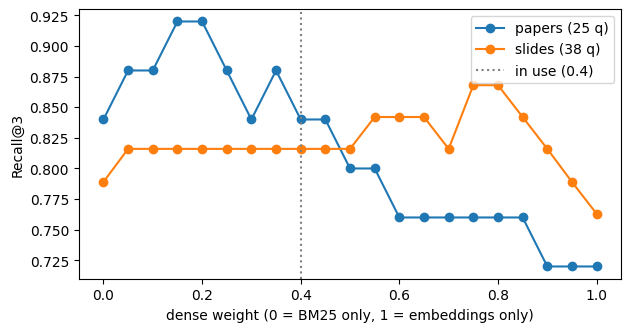

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 3.5))
for name, label in (("hybrid_weight_sweep.json", "papers (25 q)"),
                    ("hybrid_weight_sweep_slides.json", "slides (38 q)")):
    sweep = saved(name)
    weights = sorted(sweep["weights"], key=float)
    ax.plot([float(w) for w in weights],
            [sweep["weights"][w]["recall"]["recall_at_3"] for w in weights],
            marker="o", label=label)
    print(f"{label}: best Recall@3 at weight {sweep['best_recall_at_3_weight']}, "
          f"in use {sweep['weight_in_use']}")
ax.axvline(0.4, color="grey", linestyle=":", label="in use (0.4)")
ax.set_xlabel("dense weight (0 = BM25 only, 1 = embeddings only)")
ax.set_ylabel("Recall@3")
ax.legend()
plt.show()